In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random
import pandas as pd
import csv
from IPython.display import FileLink, display


In [ ]:
def laplacian_filter(image, **kwargs):
    ddepth = kwargs.get("ddepth", cv2.CV_64F)
    ksize = kwargs.get("ksize", 1)
    image_array = np.asarray(image, dtype=np.uint8)

    if len(image_array.shape) == 3 and image_array.shape[2] == 3:
        gray_img = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)  # type: ignore[arg-type]
    else:
        gray_img = image_array

    edges = cv2.Laplacian(gray_img, ddepth=ddepth, ksize=ksize)
    return np.uint8(np.clip(np.absolute(edges), 0, 255))

def blur_filter(image, **kwargs):
    ksize = kwargs.get('ksize', (5, 5))
    image_array = np.asarray(image, dtype=np.uint8)
    return cv2.blur(image_array, ksize)

def gaussian_blur_filter(image, **kwargs):
    ksize = kwargs.get('ksize', (5, 5))
    sigmaX = kwargs.get('sigmaX', 0)
    sigmaY = kwargs.get('sigmaY', 0)
    image_array = np.asarray(image, dtype=np.uint8)
    return cv2.GaussianBlur(image_array, ksize, sigmaX, sigmaY)

def sharpen_filter(image, **kwargs):
    kernel = kwargs.get("kernel", None)
    ksize = kwargs.get("ksize", 3)
    strength = kwargs.get("strength", 5)

    if kernel is None:
        if ksize % 2 == 0:
            raise ValueError("ksize must be odd")
        kernel = -1 * np.ones((ksize, ksize), dtype=np.float32)
        center = ksize // 2
        kernel[center, center] = strength + (ksize * ksize - 1)

    image_array = np.asarray(image, dtype=np.uint8)
    return cv2.filter2D(image_array, ddepth=-1, kernel=kernel)

def add_gaussian_noise(image, **kwargs):
    mean = kwargs.get("mean", 0)
    std_dev = kwargs.get("std_dev", 25)

    image_float = np.asarray(image, dtype=np.float64)
    noise = np.random.normal(mean, std_dev, image_float.shape)
    noisy_image = image_float + noise
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

def add_salt_noise(image, **kwargs):
    output = np.asarray(image).copy()
    if len(output.shape) == 2:
        row, col = output.shape
    else:
        row, col, _ = output.shape

    amount = kwargs.get("amount", 0.01)
    seed = kwargs.get("seed", None)

    if seed is not None:
        random.seed(int(seed))
        np.random.seed(int(seed))

    num_pixels = int(amount * row * col)

    for _ in range(num_pixels):
        y = random.randint(0, row - 1)
        x = random.randint(0, col - 1)
        output[y, x] = 255

    return output

def edge_detection_filter(image, **kwargs):
    ksize = kwargs.get("ksize", 3)
    dx = kwargs.get("dx", 1)
    dy = kwargs.get("dy", 1)

    gray = cv2.cvtColor(np.asarray(image, dtype=np.uint8), cv2.COLOR_BGR2GRAY)  # type: ignore[arg-type]
    sobelxy = cv2.Sobel(src=gray, ddepth=cv2.CV_64F, dx=dx, dy=dy, ksize=ksize)
    sobelxy_abs = np.absolute(sobelxy)
    sobelxy_uint8 = np.uint8(np.clip(sobelxy_abs, 0, 255))
    return cv2.cvtColor(sobelxy_uint8, cv2.COLOR_GRAY2RGB)  # type: ignore[arg-type]

def add_pepper_noise(image, **kwargs):
    amount = kwargs.get("amount", 0.01)
    seed = kwargs.get("seed", None)

    if seed is not None:
        random.seed(int(seed))
        np.random.seed(int(seed))

    output = np.asarray(image).copy()

    if len(output.shape) == 2:
        row, col = output.shape
    else:
        row, col, _ = output.shape

    number_of_pixels = int(amount * row * col)
    for _ in range(number_of_pixels):
        y = random.randint(0, row - 1)
        x = random.randint(0, col - 1)
        output[y, x] = 0

    return output

def apply_noise_filter(image, noise_type, **kwargs):
    noise_type = noise_type.lower()

    if noise_type == "gaussian":
        noisy_img = add_gaussian_noise(image, **kwargs)
    elif noise_type == "salt":
        noisy_img = add_salt_noise(image, **kwargs)
    elif noise_type == "pepper":
        noisy_img = add_pepper_noise(image, **kwargs)
    elif noise_type == "blur":
        noisy_img = blur_filter(image, **kwargs)
    elif noise_type == "gaussianb":
        noisy_img = gaussian_blur_filter(image, **kwargs)
    elif noise_type == "laplacian":
        noisy_img = laplacian_filter(image, **kwargs)
    elif noise_type == "sharpen":
        noisy_img = sharpen_filter(image, **kwargs)
    elif noise_type == "edge":
        noisy_img = edge_detection_filter(image, **kwargs)
    else:
        raise ValueError(f"Unknown filter type: {noise_type}")

    noisy_img = np.asarray(noisy_img)

    if noisy_img.ndim == 3:
        if noisy_img.shape[2] in (3, 4):
            noisy_img = cv2.cvtColor(noisy_img.astype(np.uint8), cv2.COLOR_BGR2GRAY)  # type: ignore[arg-type]
        else:
            noisy_img = noisy_img[..., 0]

    noisy_img = np.asarray(noisy_img, dtype=np.uint8)
    if noisy_img.shape != (28, 28):
        noisy_img = cv2.resize(noisy_img, (28, 28))  # type: ignore[arg-type]

    return noisy_img


In [ ]:
def sample_noise_params(noise_type):
    noise_type = noise_type.lower()
    if noise_type == 'blur' or noise_type == 'gaussianb':
        k = random.choice([1, 3, 5, 7, 9])
        if noise_type == 'gaussianb':
            sigma = random.uniform(0.5, 3.0)
            return {'ksize': (k, k), 'sigmaX': sigma, 'sigmaY': sigma}
        else:
            return {'ksize': (k, k)}
    elif noise_type == 'laplacian':
        k = random.choice([1, 3, 5, 7])
        return {'ksize': k}
    elif noise_type == 'sharpen':
        k = random.choice([1, 3, 5, 7, 9])
        return {'ksize': k}
    elif noise_type == 'salt' or noise_type == 'pepper':
        amount = random.uniform(0.01, 0.1)
        return {'amount': amount}
    elif noise_type == 'gaussian':
        std_dev = random.uniform(0, 200)
        return {'mean': 0, 'std_dev': std_dev}
    else:
        return {}

In [ ]:
class DelayedEarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, base_callback, start_epoch=20):
        super().__init__()
        self.base_callback = base_callback
        self.start_epoch = start_epoch

    def set_model(self, model):
        self.base_callback.set_model(model)

    def set_params(self, params):
        self.base_callback.set_params(params)

    def on_train_begin(self, logs=None):
        self.base_callback.on_train_begin(logs)

    def on_epoch_end(self, epoch, logs=None):
        if epoch == self.start_epoch:
            print(f"[DelayedEarlyStopping] EarlyStopping becomes active at epoch {epoch}.")
        if epoch >= self.start_epoch:
            self.base_callback.on_epoch_end(epoch, logs)

In [ ]:
def run_noise_experiment(
    noise_type,
    sample_params_func,
    test_params_list,
    epochs=500,
    patience=20,
    validation_split=0.1,
    verbose=1,
    csv_save_path=None
):
    from copy import deepcopy
    experiment_results = []

    # Load and prepare clean data
    (train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

    # Convert to uint8 and squeeze to (28, 28)
    train_images = np.squeeze(train_images).astype("uint8")
    test_images = np.squeeze(test_images).astype("uint8")

    for test_param in test_params_list:
        print(f"\n--- Training with noise param: {test_param} ---")
        tf.keras.backend.clear_session()

        # Reset learning rate log for this run
        global lr_log
        lr_log = []

 # Sample random noise parameters for training
        train_params = sample_params_func(noise_type)

        # Apply random noise to training images, sampling parameters per image
        noisy_train = np.array([
            apply_noise_filter(img, noise_type, **sample_params_func(noise_type))
            for img in train_images
        ])
        noisy_train = np.expand_dims(noisy_train, axis=-1).astype("float32") / 255.0


        print("Displaying sample noisy training images:")
        num_samples_to_show = 5
        plt.figure(figsize=(10, 2))
        for i in range(num_samples_to_show):
            plt.subplot(1, num_samples_to_show, i+1)
            plt.imshow(noisy_train[i].squeeze(), cmap='gray')
            plt.title(f"Label: {train_labels[i]}")
            plt.axis('off')
        plt.show()

        # Apply test noise (converted to dict if needed)
        test_param_dict = (
            {"ksize": test_param} if isinstance(test_param, tuple)
            else test_param if isinstance(test_param, dict)
            else {"param": test_param}
        )

        noisy_test = np.array([
            apply_noise_filter(img, noise_type, **test_param_dict)
            for img in test_images
        ])
        noisy_test = np.expand_dims(noisy_test, axis=-1).astype("float32") / 255.0

        # Create new model
        model = create_model()

        # Create callbacks
        lr_callback = tf.keras.callbacks.LearningRateScheduler(custom_lr_scheduler)
        early_stop_base = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=patience, restore_best_weights=True)
        early_stop_callback = DelayedEarlyStopping(base_callback=early_stop_base, start_epoch=20)

        # Train the model
        history = model.fit(
            noisy_train, train_labels,
            validation_split=validation_split,
            epochs=epochs,
            batch_size=32,
            callbacks=[lr_callback, early_stop_callback],
            verbose=verbose
        )

        # Evaluate on noisy test
        test_loss, test_acc = model.evaluate(noisy_test, test_labels, verbose=0)

        # Collect result summary
        result = show_summary_table(
            model=model,
            history=history,
            test_images=noisy_test,
            test_labels=test_labels,
            noise_type=noise_type + "_test",
            noise_kwargs={"test_param": test_param},
            early_stop_callback=early_stop_callback
        )

        print("Run summary:", result)
        experiment_results.append(result)

        # Plot training history
        plot_training_history_static(history)
        plot_learning_rate_static(lr_log)

    # Save all results to CSV if path provided
    if csv_save_path:
        df = pd.DataFrame(experiment_results)
        df.to_csv(csv_save_path, index=False)
        print(f"\nSaved results CSV to: {csv_save_path}")
        display(FileLink(csv_save_path))

    return experiment_results

In [ ]:
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
lr_log = []

def custom_lr_scheduler(epoch, lr):
    if epoch < 5:
        lr = lr + 0.0005
    elif epoch % 10 == 0:
        lr = lr * 0.8
    lr_log.append(lr)
    return lr

In [ ]:
def plot_training_history_static(history):
    acc = history.history['accuracy']
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history['loss']
    val_loss = history.history.get('val_loss', [])
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-o', label='Training Accuracy')
    if val_acc:
        plt.plot(epochs, val_acc, 'g-o', label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-o', label='Training Loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'g-o', label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

def plot_learning_rate_static(lr_log):
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(lr_log) + 1), lr_log, marker='o', color='purple')
    plt.title('Learning Rate per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
def view_classify(image, probabilities):
    fig, (ax1, ax2) = plt.subplots(figsize=(6,9), ncols=2)
    ax1.imshow(image.squeeze(), cmap='gray')
    ax1.axis('off')
    ax2.barh(np.arange(10), probabilities)
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(10))
    ax2.set_yticklabels(np.arange(10))
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)
    plt.tight_layout()
    plt.show()


In [ ]:
def show_summary_table(model, history, test_images, test_labels, noise_type, noise_kwargs, early_stop_callback):
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history.get('val_accuracy', ['N/A'])[-1]
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)

    if isinstance(early_stop_callback, DelayedEarlyStopping):
        patience = early_stop_callback.base_callback.patience
    else:
        patience = early_stop_callback.patience

    result_dict = {
        "Noise Type": noise_type,
        "Train Accuracy": round(final_train_acc, 4),
        "Validation Accuracy": round(final_val_acc, 4) if final_val_acc != 'N/A' else 'N/A',
        "Test Accuracy": round(test_acc, 4),
        "Epochs Run": len(history.history['accuracy']),
        "Optimizer": "Adam",
        "Initial LR": "0.001 (default)",
        "Batch Size": 32,
        "Hidden Layers": "128, 64",
        "Activation Functions": "ReLU (hidden), Softmax (output)",
        "LR Scheduler": "Custom (warmup + decay)",
        "Early Stop Patience": patience
    }

    for key, value in noise_kwargs.items():
        result_dict[f"Noise Param: {key}"] = value


    return result_dict

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- Training with noise param: 0 ---
Displaying sample noisy training images:


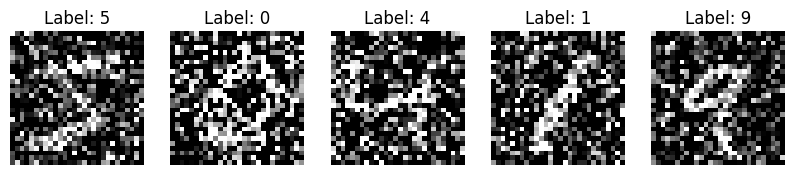

Epoch 1/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7598 - loss: 0.7422 - val_accuracy: 0.9013 - val_loss: 0.3066 - learning_rate: 0.0015
Epoch 2/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8958 - loss: 0.3213 - val_accuracy: 0.9002 - val_loss: 0.3015 - learning_rate: 0.0020
Epoch 3/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9168 - loss: 0.2562 - val_accuracy: 0.9127 - val_loss: 0.2901 - learning_rate: 0.0025
Epoch 4/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9290 - loss: 0.2141 - val_accuracy: 0.9140 - val_loss: 0.2910 - learning_rate: 0.0030
Epoch 5/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9361 - loss: 0.1906 - val_accuracy: 0.9118 - val_loss: 0.2912 - learning_rate: 0.0035
Epoch 6/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9451 - loss: 0.1642 - val_accuracy: 0.9165 - val_loss: 0.2837 - learning_rate: 0.0035
Epoch 7/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 

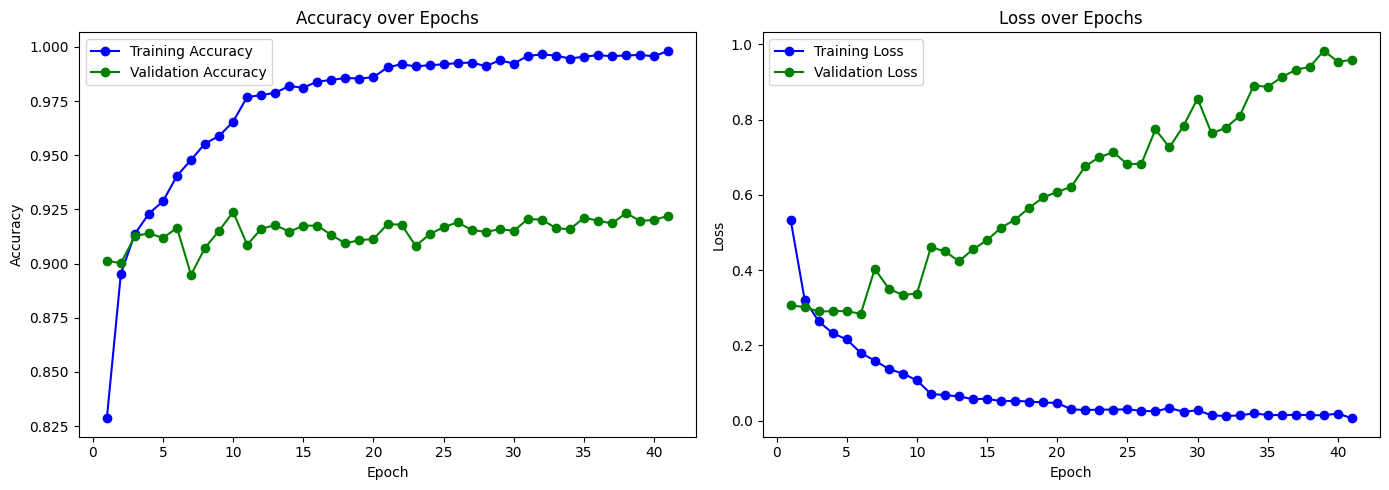

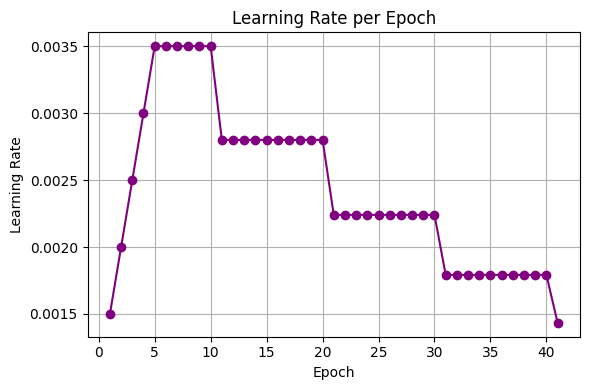


--- Training with noise param: 50 ---
Displaying sample noisy training images:


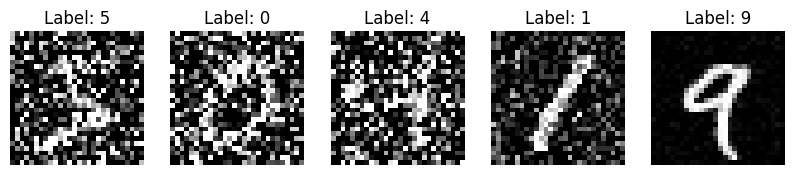

Epoch 1/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7553 - loss: 0.7583 - val_accuracy: 0.9048 - val_loss: 0.3033 - learning_rate: 0.0015
Epoch 2/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8922 - loss: 0.3367 - val_accuracy: 0.9118 - val_loss: 0.2811 - learning_rate: 0.0020
Epoch 3/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9173 - loss: 0.2572 - val_accuracy: 0.9102 - val_loss: 0.2849 - learning_rate: 0.0025
Epoch 4/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9278 - loss: 0.2204 - val_accuracy: 0.9057 - val_loss: 0.3123 - learning_rate: 0.0030
Epoch 5/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9344 - loss: 0.2014 - val_accuracy: 0.9092 - val_loss: 0.3096 - learning_rate: 0.0035
Epoch 6/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9441 - loss: 0.1713 - val_accuracy: 0.9082 - val_loss: 0.3247 - learning_rate: 0.0035
Epoch 7/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.

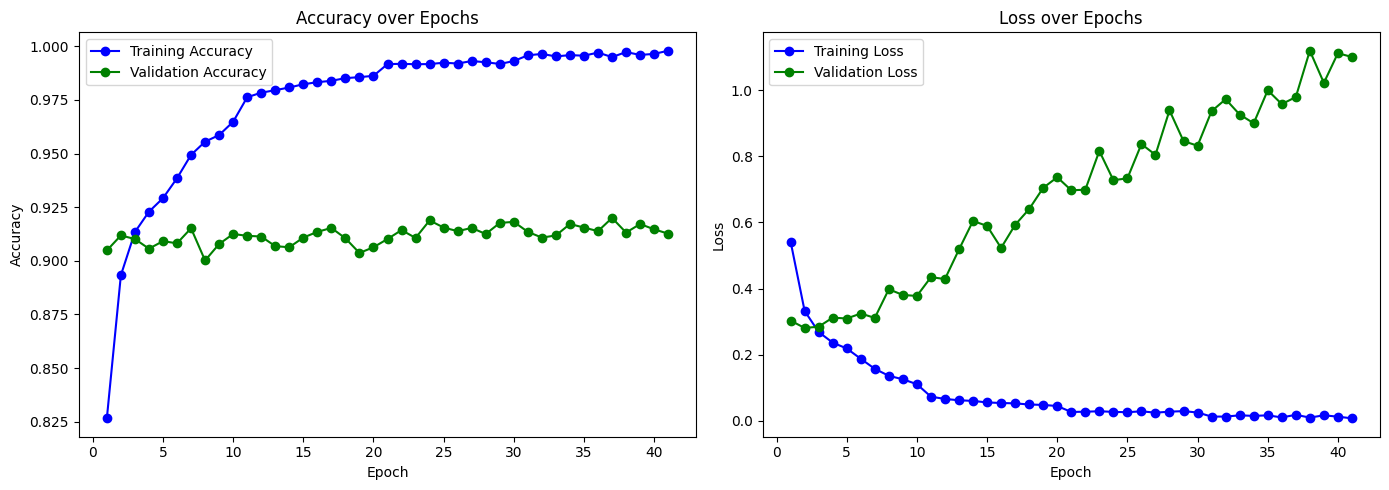

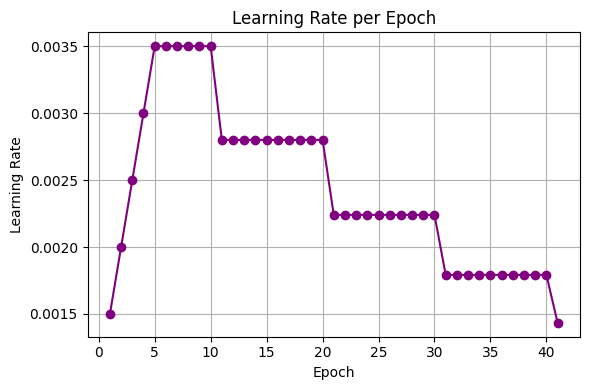


--- Training with noise param: 100 ---
Displaying sample noisy training images:


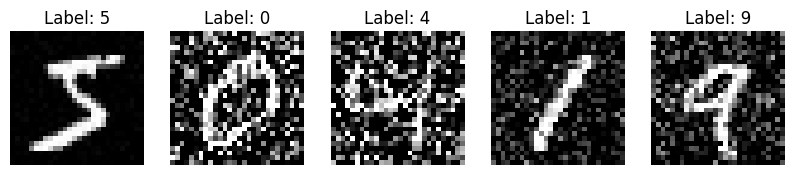

Epoch 1/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7568 - loss: 0.7473 - val_accuracy: 0.9062 - val_loss: 0.2935 - learning_rate: 0.0015
Epoch 2/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8970 - loss: 0.3202 - val_accuracy: 0.9033 - val_loss: 0.2875 - learning_rate: 0.0020
Epoch 3/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9178 - loss: 0.2512 - val_accuracy: 0.9177 - val_loss: 0.2730 - learning_rate: 0.0025
Epoch 4/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9285 - loss: 0.2152 - val_accuracy: 0.9040 - val_loss: 0.3186 - learning_rate: 0.0030
Epoch 5/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9397 - loss: 0.1824 - val_accuracy: 0.9055 - val_loss: 0.3255 - learning_rate: 0.0035
Epoch 6/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9473 - loss: 0.1616 - val_accuracy: 0.8952 - val_loss: 0.3561 - learning_rate: 0.0035
Epoch 7/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0

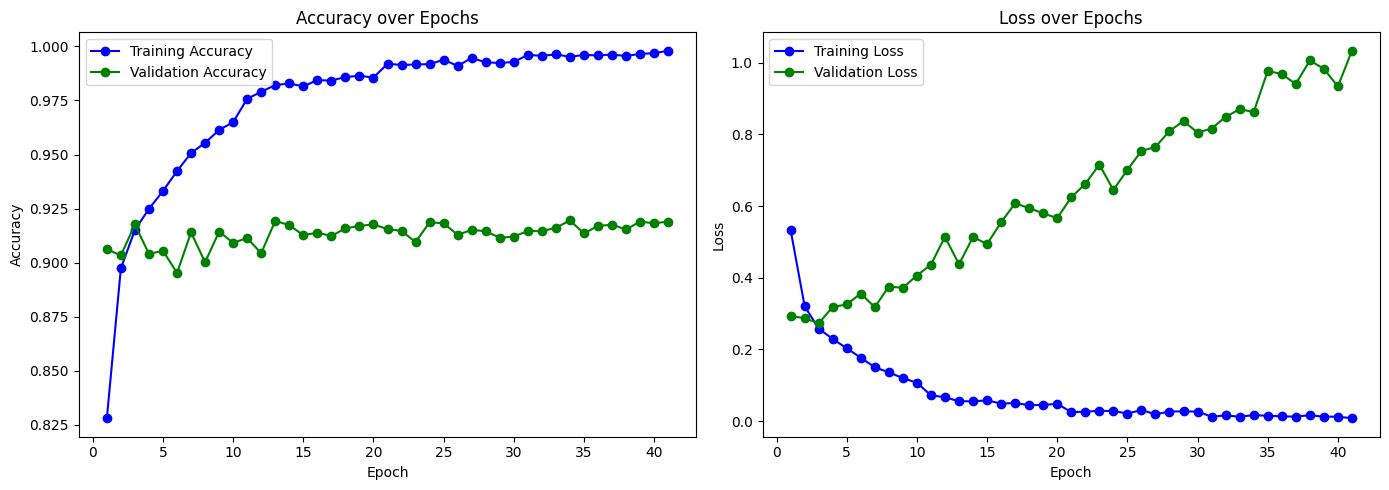

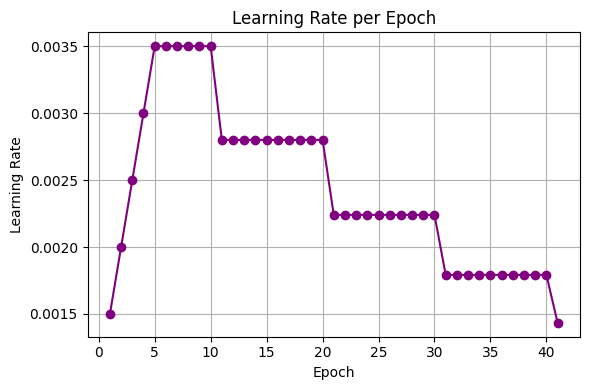


--- Training with noise param: 150 ---
Displaying sample noisy training images:


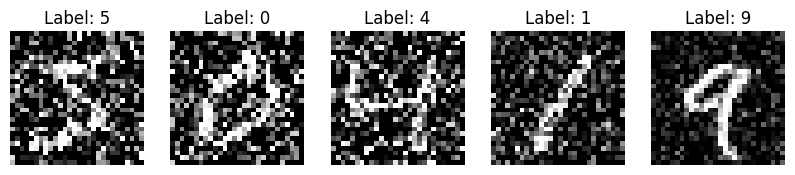

Epoch 1/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7564 - loss: 0.7558 - val_accuracy: 0.9075 - val_loss: 0.2931 - learning_rate: 0.0015
Epoch 2/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8973 - loss: 0.3155 - val_accuracy: 0.9140 - val_loss: 0.2744 - learning_rate: 0.0020
Epoch 3/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9206 - loss: 0.2429 - val_accuracy: 0.9152 - val_loss: 0.2665 - learning_rate: 0.0025
Epoch 4/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9304 - loss: 0.2138 - val_accuracy: 0.9060 - val_loss: 0.3004 - learning_rate: 0.0030
Epoch 5/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9359 - loss: 0.1935 - val_accuracy: 0.9042 - val_loss: 0.3235 - learning_rate: 0.0035
Epoch 6/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9481 - loss: 0.1569 - val_accuracy: 0.9122 - val_loss: 0.3262 - learning_rate: 0.0035
Epoch 7/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.

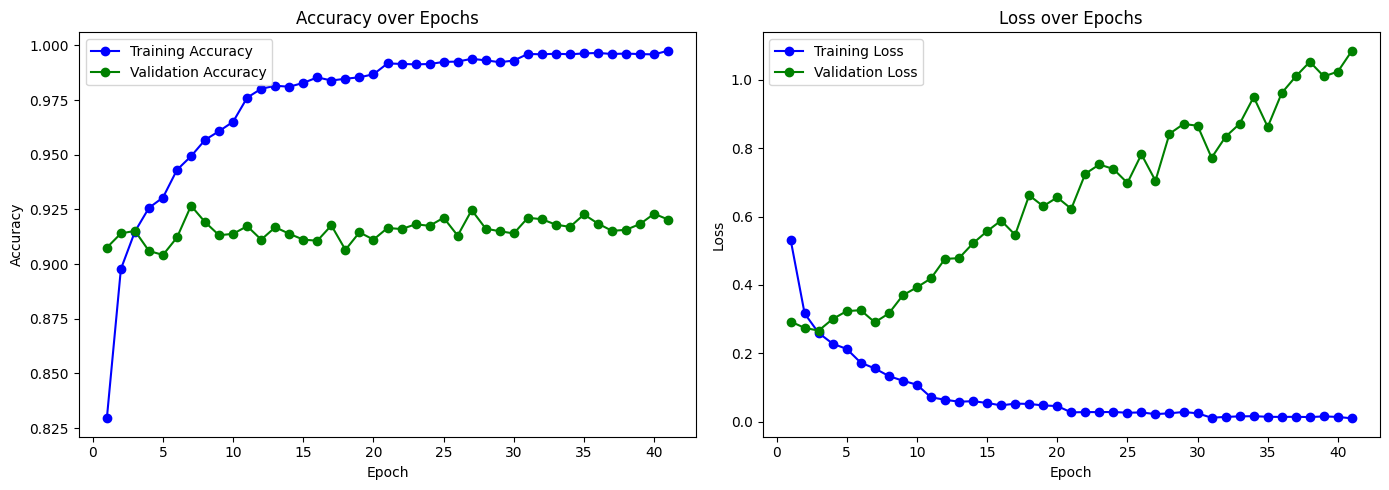

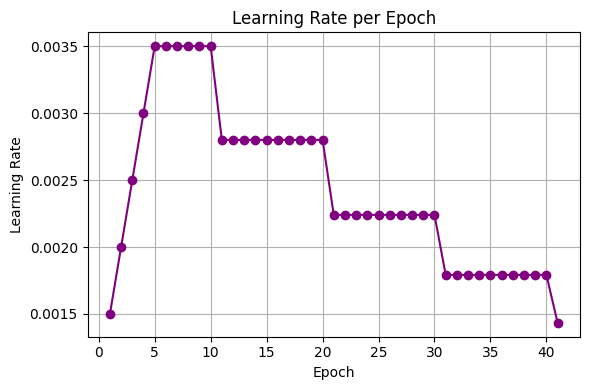


--- Training with noise param: 200 ---
Displaying sample noisy training images:


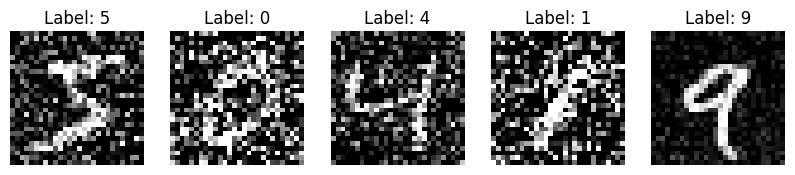

Epoch 1/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7608 - loss: 0.7378 - val_accuracy: 0.8928 - val_loss: 0.3351 - learning_rate: 0.0015
Epoch 2/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8962 - loss: 0.3149 - val_accuracy: 0.9102 - val_loss: 0.2730 - learning_rate: 0.0020
Epoch 3/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9216 - loss: 0.2442 - val_accuracy: 0.9115 - val_loss: 0.2712 - learning_rate: 0.0025
Epoch 4/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9307 - loss: 0.2113 - val_accuracy: 0.9188 - val_loss: 0.2602 - learning_rate: 0.0030
Epoch 5/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9363 - loss: 0.1880 - val_accuracy: 0.9140 - val_loss: 0.2922 - learning_rate: 0.0035
Epoch 6/500
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9444 - loss: 0.1631 - val_accuracy: 0.9147 - val_loss: 0.3228 - learning_rate: 0.0035
Epoch 7/500
 715/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy

KeyboardInterrupt: 

In [ ]:
test_blur_ksizes = [0, 50, 100, 150, 200]

results = run_noise_experiment(
    noise_type='gaussian',
    sample_params_func=sample_noise_params,
    test_params_list=test_blur_ksizes,
    epochs=500,
    patience=20,
    validation_split=0.1,
    verbose=1,
    csv_save_path='noise_experiment_summary.csv'

)
